# Predicción del Peso Final de Pollos de Engorde
## Reto Técnico – Gestión Analítica e Información Técnica
### Lorena Davila Guaman

**Objetivo:** Desarrollar un modelo de Machine Learning para predecir el peso final de los pollos de engorde a partir de variables productivas, aplicando técnicas de análisis de datos, preparación de información y modelado predictivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mostrar gráficos dentro del notebook
%matplotlib inline

# 1. Carga y comprensión de los datos

En esta sección se realiza la carga de la base de datos y una revisión inicial de su estructura, tipos de variables y calidad de la información.

In [2]:
df = pd.read_excel("Data_caso_practico.xlsx")
df.head()

,ID_Lote,Edad_Dias,Consumo_Alimento_g_dia,Temperatura_C,Humedad_%,Densidad_Aves_m2,Mortalidad_%,Sexo,Linea_Genetica,Peso_Inicial_g,Peso_Final_g
0,1,35,177.4,23.1,52.5,8.4,1.00,Macho,Arbor Acres,47.1,2833.5
1,2,1,46.1,32.5,77.4,9.8,3.86,Hembra,Arbor Acres,45.1,312.6
2,3,41,181.5,23.8,63.8,17.6,1.08,Macho,Ross 308,42.2,3298.3
3,4,16,96.6,27.3,72.6,12.1,2.60,Macho,Arbor Acres,43.5,1539.7
4,5,3,47.1,24.6,77.1,15.7,0.97,Hembra,Cobb 500,41.9,517.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Lote                 1000 non-null   int64  
 1   Edad_Dias               1000 non-null   int64  
 2   Consumo_Alimento_g_dia  1000 non-null   float64
 3   Temperatura_C           1000 non-null   float64
 4   Humedad_%               1000 non-null   float64
 5   Densidad_Aves_m2        1000 non-null   float64
 6   Mortalidad_%            1000 non-null   float64
 7   Sexo                    1000 non-null   object 
 8   Linea_Genetica          1000 non-null   object 
 9   Peso_Inicial_g          1000 non-null   float64
 10  Peso_Final_g            1000 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 86.1+ KB


In [4]:
df.shape
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 1000
Columnas: 11


## Comprensión de los datos
La base de datos contiene 1000 registros históricos de producción de pollos de engorde y 11 variables relacionadas con características productivas, ambientales y biológicas.

La variable objetivo del análisis es **Peso_Final_g**, correspondiente al peso final alcanzado por cada ave.

Las variables disponibles incluyen información sobre edad, consumo de alimento, condiciones ambientales, densidad de aves, mortalidad, sexo, línea genética y peso inicial.

In [5]:
df.isnull().sum()

ID_Lote                   0
Edad_Dias                 0
Consumo_Alimento_g_dia    0
Temperatura_C             0
Humedad_%                 0
Densidad_Aves_m2          0
Mortalidad_%              0
Sexo                      0
Linea_Genetica            0
Peso_Inicial_g            0
Peso_Final_g              0
dtype: int64

## Calidad de la información

Se realizó una revisión de valores faltantes en todas las variables del conjunto de datos.

Los resultados muestran que no existen registros nulos, por lo que no fue necesario aplicar técnicas de imputación o eliminación de observaciones.

Esto garantiza que todas las variables se encuentran disponibles para el análisis exploratorio y el modelado predictivo.

In [6]:
df.describe(include='all')

,ID_Lote,Edad_Dias,Consumo_Alimento_g_dia,Temperatura_C,Humedad_%,Densidad_Aves_m2,Mortalidad_%,Sexo,Linea_Genetica,Peso_Inicial_g,Peso_Final_g
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.000000,1000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hembra,Arbor Acres,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,511,339,NaN,NaN
mean,500.500000,21.444000,122.04170,26.951900,64.740000,12.869300,2.552190,NaN,NaN,43.065800,1847.626500
std,288.819436,12.163092,48.82485,4.050867,11.336014,2.828793,1.219245,NaN,NaN,2.867367,909.391305
min,1.000000,1.000000,20.00000,20.000000,45.000000,8.000000,0.000000,NaN,NaN,38.000000,135.000000
25%,250.750000,11.000000,79.57500,23.500000,55.375000,10.500000,1.737500,NaN,NaN,40.700000,1077.700000
50%,500.500000,22.000000,121.00000,26.800000,64.700000,12.900000,2.485000,NaN,NaN,43.000000,1844.850000
75%,750.250000,32.000000,163.35000,30.525000,74.200000,15.300000,3.375000,NaN,NaN,45.425000,2599.375000


## Estadísticas descriptivas

Se realizó un análisis descriptivo de las variables numéricas y categóricas incluidas en la base de datos.

### Variables categóricas

Se identificaron dos variables categóricas:

- **Sexo**, con dos categorías (Macho y Hembra), siendo Hembra la categoría más frecuente con 511 registros.
- **Linea_Genetica**, con tres categorías diferentes, siendo Arbor Acres la más representativa con 339 registros.

### Variables numéricas

- La edad de las aves oscila entre 1 y 42 días, con un promedio de 21,44 días.

- El consumo diario de alimento presenta una media de 122,04 gramos, con valores entre 20 y 231,1 gramos por día.

- La temperatura registrada varía entre 20 °C y 34 °C, mientras que la humedad relativa fluctúa entre 45 % y 85 %.

- La densidad de alojamiento presenta un promedio de 12,87 aves por metro cuadrado y la mortalidad promedio observada es de 2,55 %.

- El peso inicial registra una media de 43,07 gramos, mientras que la variable objetivo **Peso_Final_g** presenta un promedio de 1.847,63 gramos, con valores comprendidos entre 135 y 3.596,3 gramos.

- La amplitud observada en el peso final sugiere la existencia de variabilidad productiva que puede ser explicada por las variables disponibles en el conjunto de datos.

En general, las variables presentan rangos consistentes y coherentes desde el punto de vista productivo. No se observan anomalías evidentes en esta etapa del análisis, por lo que se continuará con la exploración gráfica y detección de posibles valores atípicos.

# 2. Análisis Exploratorio de Datos

En esta sección se exploran las distribuciones de las variables, se identifican posibles valores atípicos y se analizan las relaciones entre las variables explicativas y la variable objetivo.

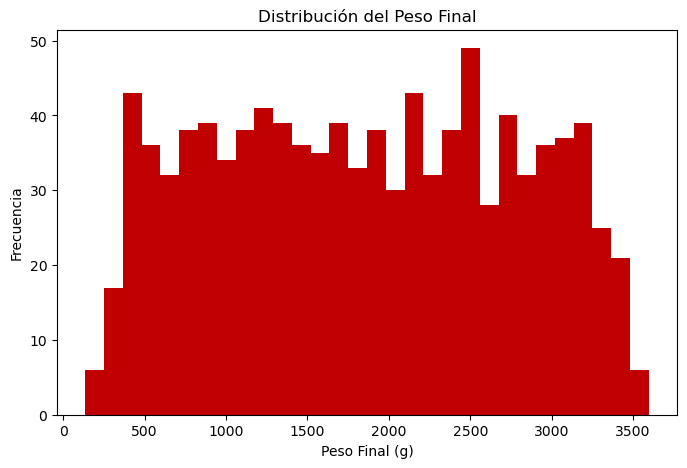

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Peso_Final_g'], bins=30, color='#C00000')
plt.title('Distribución del Peso Final')
plt.xlabel('Peso Final (g)')
plt.ylabel('Frecuencia')
plt.show()

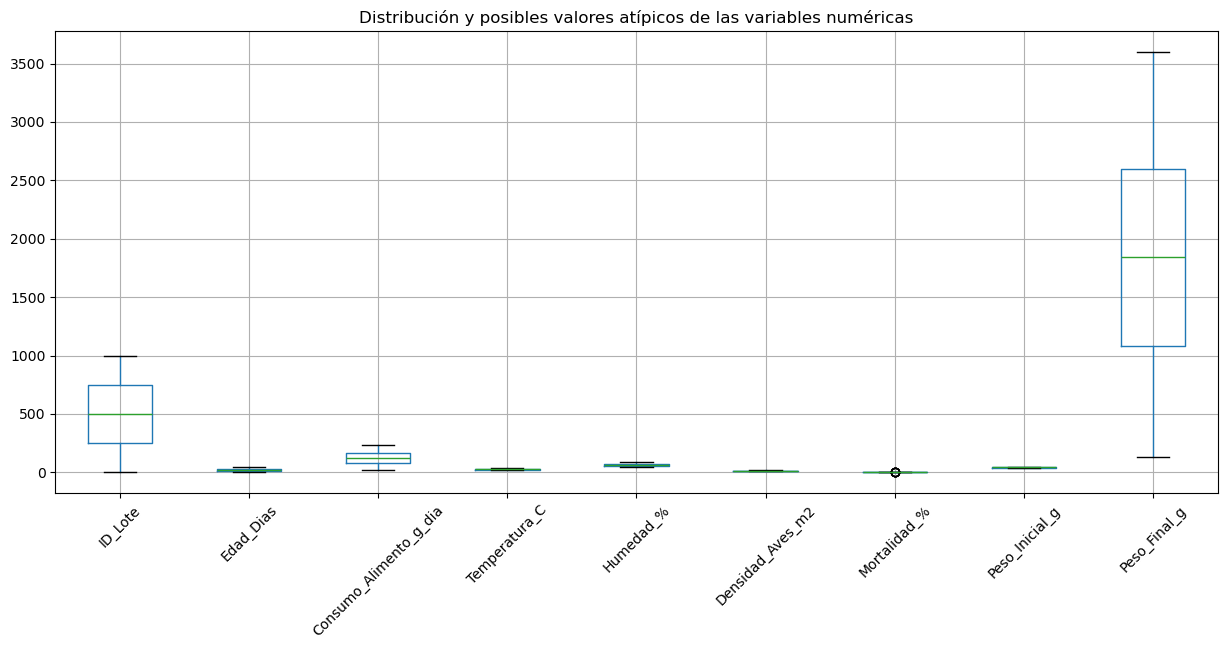

In [8]:
plt.figure(figsize=(15,6))
df.boxplot()
plt.xticks(rotation=45)
plt.title('Distribución y posibles valores atípicos de las variables numéricas')
plt.show()

Se revisaron posibles valores atípicos mediante boxplots. No se eliminaron registros, ya que no se identificaron inconsistencias evidentes y los valores observados pueden responder a variabilidad propia del proceso productivo.

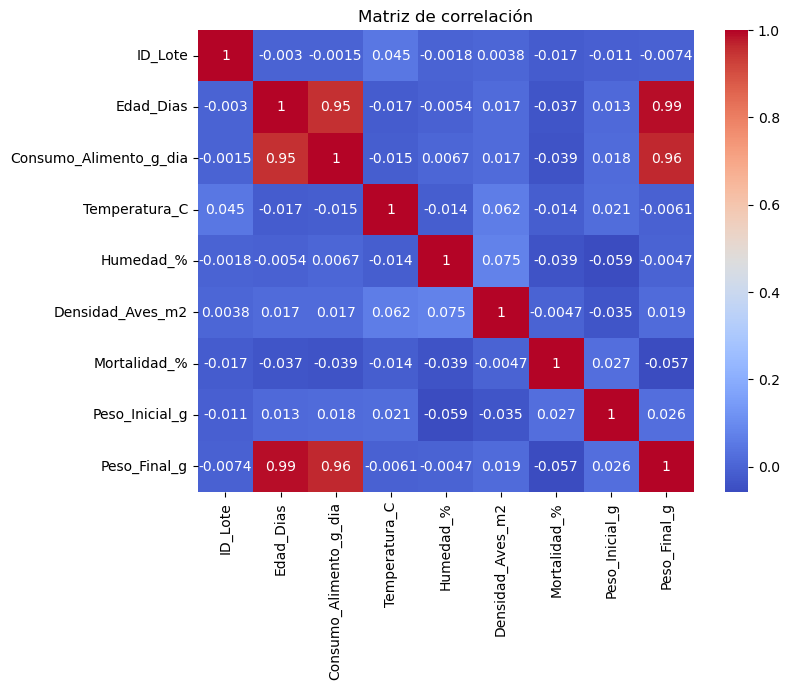

In [9]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title('Matriz de correlación')
plt.show()

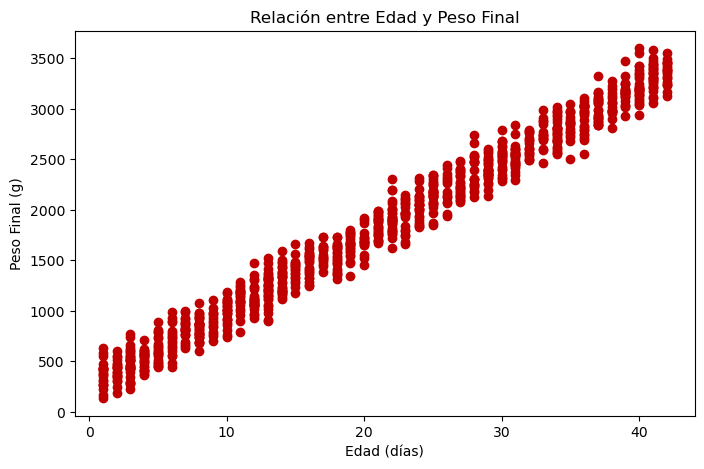

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['Edad_Dias'], df['Peso_Final_g'],color='#C00000')
plt.xlabel('Edad (días)')
plt.ylabel('Peso Final (g)')
plt.title('Relación entre Edad y Peso Final')
plt.show()

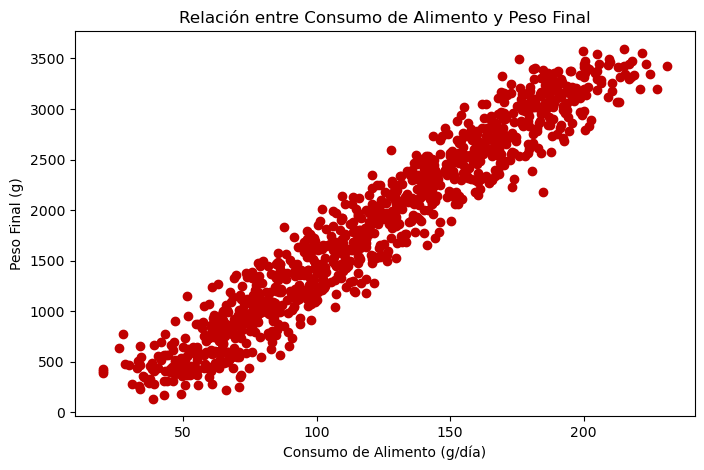

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df['Consumo_Alimento_g_dia'], df['Peso_Final_g'],color='#C00000')
plt.xlabel('Consumo de Alimento (g/día)')
plt.ylabel('Peso Final (g)')
plt.title('Relación entre Consumo de Alimento y Peso Final')
plt.show()

In [12]:
corr = df.corr(numeric_only=True)

corr["Peso_Final_g"].sort_values(ascending=False)

Peso_Final_g              1.000000
Edad_Dias                 0.990441
Consumo_Alimento_g_dia    0.964765
Peso_Inicial_g            0.025775
Densidad_Aves_m2          0.018883
Humedad_%                -0.004698
Temperatura_C            -0.006103
ID_Lote                  -0.007427
Mortalidad_%             -0.056876
Name: Peso_Final_g, dtype: float64

## Análisis de correlación

A partir de la matriz de correlación y de los gráficos de dispersión, se evaluó la relación entre las variables numéricas y la variable objetivo Peso_Final_g.

Los resultados muestran una fuerte asociación positiva entre la edad de las aves y el peso final (0,99), así como entre el consumo diario de alimento y el peso final (0,96). Los gráficos de dispersión evidencian una tendencia creciente consistente, confirmando que ambas variables son factores determinantes en el desempeño productivo.

Por otro lado, variables como temperatura, humedad, densidad de aves y mortalidad presentan una relación considerablemente menor con el peso final dentro de la muestra analizada.

Con base en estos resultados, Edad_Dias y Consumo_Alimento_g_dia fueron consideradas variables clave para el desarrollo de los modelos predictivos.

# 3. Preparación de los datos

Con el objetivo de preparar la información para el entrenamiento de modelos de Machine Learning, se realizó la transformación de las variables categóricas a formato numérico.

Las variables Sexo y Linea_Genetica fueron codificadas mediante la técnica Label Encoding, permitiendo que los algoritmos puedan procesar adecuadamente esta información durante el entrenamiento.

In [13]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()

df_model['Sexo'] = le.fit_transform(df_model['Sexo'])
df_model['Linea_Genetica'] = le.fit_transform(df_model['Linea_Genetica'])

df_model.head()

,ID_Lote,Edad_Dias,Consumo_Alimento_g_dia,Temperatura_C,Humedad_%,Densidad_Aves_m2,Mortalidad_%,Sexo,Linea_Genetica,Peso_Inicial_g,Peso_Final_g
0,1,35,177.4,23.1,52.5,8.4,1.00,1,0,47.1,2833.5
1,2,1,46.1,32.5,77.4,9.8,3.86,0,0,45.1,312.6
2,3,41,181.5,23.8,63.8,17.6,1.08,1,2,42.2,3298.3
3,4,16,96.6,27.3,72.6,12.1,2.60,1,0,43.5,1539.7
4,5,3,47.1,24.6,77.1,15.7,0.97,0,1,41.9,517.5


In [14]:
# Creación de característica derivada

df_model['Consumo_Acumulado_Estimado'] = (
    df_model['Edad_Dias'] *
    df_model['Consumo_Alimento_g_dia']
)

df_model[['Edad_Dias',
          'Consumo_Alimento_g_dia',
          'Consumo_Acumulado_Estimado']].head()

,Edad_Dias,Consumo_Alimento_g_dia,Consumo_Acumulado_Estimado
0,35,177.4,6209.0
1,1,46.1,46.1
2,41,181.5,7441.5
3,16,96.6,1545.6
4,3,47.1,141.3


Como parte de la preparación de los datos, se creó la variable Consumo_Acumulado_Estimado, calculada a partir de Edad_Dias y Consumo_Alimento_g_dia.

Esta variable busca aproximar el consumo acumulado del ave durante su ciclo productivo, considerando que el peso final puede verse influenciado tanto por el nivel de consumo como por el tiempo de crecimiento.

La incorporación de esta característica permite evaluar si la interacción entre ambas variables aporta información adicional al modelo predictivo.

In [15]:
X = df_model.drop(['Peso_Final_g', 'ID_Lote'], axis=1)

y = df_model['Peso_Final_g']

Una vez preparadas las variables y generadas las características derivadas, se definieron las variables predictoras (X) y la variable objetivo (y) para el entrenamiento de los modelos.

Se excluyó la variable ID_Lote debido a que corresponde a un identificador único de registro y no aporta información explicativa relevante para la predicción del peso final.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Registros entrenamiento: {X_train.shape[0]}")
print(f"Registros prueba: {X_test.shape[0]}")
print(f"Variables predictoras: {X_train.shape[1]}")

Registros entrenamiento: 800
Registros prueba: 200
Variables predictoras: 10


Los datos fueron divididos en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%), permitiendo evaluar el desempeño de los modelos sobre observaciones no utilizadas durante el entrenamiento.

# 4. Modelado Predictivo

## Modelo 1: Regresión Lineal

Como línea base se implementó un modelo de Regresión Lineal, permitiendo evaluar la capacidad predictiva de las variables disponibles sobre el peso final de las aves.

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²: {r2_lr:.4f}")

MAE: 72.07
RMSE: 90.13
R²: 0.9907


El modelo de Regresión Lineal obtuvo un coeficiente de determinación (R²) de 0,9907, evidenciando una alta capacidad para explicar la variabilidad observada en el peso final de las aves.

Los errores obtenidos (MAE y RMSE) indican un nivel de precisión adecuado para el problema analizado.

## Modelo 2: Random Forest

Posteriormente se evaluó un modelo Random Forest con el objetivo de capturar posibles relaciones no lineales entre las variables explicativas y la variable objetivo.

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [20]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

MAE: 84.85
RMSE: 106.71
R²: 0.9870


El modelo Random Forest alcanzó un coeficiente de determinación (R²) de 0,9870, mostrando también un desempeño predictivo elevado.

Sin embargo, presentó errores de predicción ligeramente superiores respecto al modelo de Regresión Lineal.

# 5. Comparación de Modelos

Con el fin de identificar el modelo con mejor capacidad predictiva, se comparó el desempeño de la Regresión Lineal y Random Forest utilizando métricas de evaluación para problemas de regresión.

Las métricas consideradas fueron el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el coeficiente de determinación (R²), permitiendo evaluar la precisión y capacidad explicativa de cada modelo.

In [21]:
resultados = pd.DataFrame({
    'Modelo':['Regresión Lineal','Random Forest'],
    'MAE':[mae_lr,mae_rf],
    'RMSE':[rmse_lr,rmse_rf],
    'R2':[r2_lr,r2_rf]
})

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,72.069728,90.133910,0.990697
1,Random Forest,84.851065,106.708303,0.986961


Se comparó el desempeño de los modelos utilizando las métricas MAE, RMSE y R².

Los resultados muestran que la Regresión Lineal obtuvo el mejor desempeño general, presentando menores errores de predicción (MAE y RMSE) y un mayor coeficiente de determinación (R²).

El valor de R² superior a 0,99 indica que el modelo es capaz de explicar aproximadamente el 99% de la variabilidad observada en el peso final de las aves.

Estos resultados sugieren que la relación entre las variables explicativas y el peso final presenta un comportamiento predominantemente lineal dentro de la muestra analizada.

Adicionalmente, la incorporación de la variable derivada Consumo_Acumulado_Estimado contribuyó a una ligera mejora en el desempeño de la Regresión Lineal, evidenciando el aporte del proceso de preparación y transformación de datos realizado previamente.

# 6. Importancia de Variables

Con el objetivo de identificar los factores con mayor influencia en la predicción del peso final, se analizó la importancia relativa de las variables mediante el modelo Random Forest.

Este análisis permite comprender cuáles son las variables que aportan mayor información al modelo y generan un mayor impacto sobre las predicciones realizadas.

In [22]:
# Importancia de variables del modelo Random Forest

importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
})

# Convertir a porcentaje
importancias['Importancia (%)'] = (
    importancias['Importancia'] * 100
).round(2)

# Ordenar de mayor a menor importancia
importancias = importancias.sort_values(
    by='Importancia (%)',
    ascending=False
)

# Crear versión para presentación con símbolo %
importancias_mostrar = importancias[['Variable', 'Importancia (%)']].copy()

importancias_mostrar['Importancia (%)'] = (
    importancias_mostrar['Importancia (%)']
    .astype(str) + '%'
)

# Mostrar tabla final
importancias_mostrar

,Variable,Importancia (%)
9,Consumo_Acumulado_Estimado,80.54%
0,Edad_Dias,18.37%
6,Sexo,0.24%
8,Peso_Inicial_g,0.15%
2,Temperatura_C,0.14%
5,Mortalidad_%,0.14%
1,Consumo_Alimento_g_dia,0.13%
3,Humedad_%,0.13%
4,Densidad_Aves_m2,0.11%
7,Linea_Genetica,0.04%


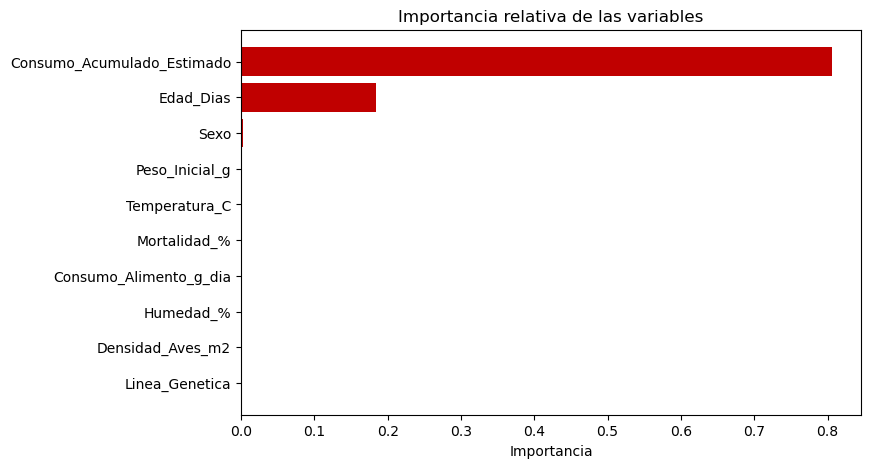

In [23]:
plt.figure(figsize=(8,5))
plt.barh(
    importancias['Variable'],
    importancias['Importancia'],
    color='#C00000'   # Rojo corporativo
)

plt.title('Importancia relativa de las variables')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()

plt.show()

Los resultados muestran que Consumo_Acumulado_Estimado es la variable con mayor capacidad explicativa dentro del modelo, concentrando aproximadamente el 81% de la importancia total.

Esta variable integra información relacionada con la edad de las aves y el consumo diario de alimento, factores que previamente habían mostrado las mayores correlaciones con el peso final durante el análisis exploratorio.

La variable Edad_Dias mantiene una contribución relevante dentro del modelo, mientras que el resto de variables presentan una influencia considerablemente menor sobre las predicciones realizadas.

Estos resultados sugieren que la combinación entre tiempo de crecimiento y consumo de alimento constituye el principal factor asociado al peso final de las aves dentro de la muestra analizada.

# 7. Hallazgos Principales

- La base de datos analizada presentó una adecuada calidad de información, sin registros nulos ni inconsistencias relevantes que afectaran el proceso de modelado.
  
- El análisis exploratorio evidenció una fuerte relación positiva entre Edad_Dias y Peso_Final_g (0,99), así como entre Consumo_Alimento_g_dia y Peso_Final_g (0,96), identificándose como las variables con mayor asociación respecto a la variable objetivo.
  
- Como parte de la preparación de los datos, se creó la variable derivada Consumo_Acumulado_Estimado, integrando información relacionada con la edad de las aves y el consumo diario de alimento.
  
- La Regresión Lineal obtuvo el mejor desempeño entre los modelos evaluados, alcanzando un R² de 0,9907, un MAE de 72,07 gramos y un RMSE de 90,13 gramos.
  
- El análisis de importancia de variables realizado mediante Random Forest identificó a Consumo_Acumulado_Estimado como la variable con mayor influencia dentro del modelo, concentrando aproximadamente el 80,54% de la importancia total.

- Los resultados obtenidos muestran que la combinación entre tiempo de crecimiento y consumo de alimento constituye el principal factor asociado al peso final de las aves dentro del conjunto de datos analizado.

# 8. Recomendaciones

- Mantener un seguimiento continuo de variables relacionadas con la edad de las aves y el consumo de alimento, debido a su alta influencia sobre el peso final alcanzado durante el ciclo productivo.
  
- Incorporar variables derivadas con sentido productivo durante la etapa de preparación de datos, ya que pueden aportar información adicional y mejorar la capacidad explicativa de los modelos predictivos.

- Evaluar la incorporación de nuevas variables productivas, ambientales y de manejo que permitan enriquecer futuros análisis y fortalecer los procesos de predicción.

- Implementar herramientas de monitoreo y visualización que faciliten el seguimiento de indicadores productivos y la identificación temprana de desviaciones respecto a los objetivos establecidos.

- Actualizar periódicamente los modelos con información reciente para mantener la precisión de las predicciones y adaptarse a posibles cambios en las condiciones de producción.

## 9. Conclusiones

- Se desarrolló un modelo de Machine Learning para predecir el peso final de pollos de engorde utilizando información productiva, ambiental y biológica proveniente de registros históricos de producción.

- El análisis exploratorio permitió identificar que la edad de las aves y el consumo diario de alimento presentan la mayor relación con el peso final, registrando correlaciones de 0,99 y 0,96 respectivamente.

- Durante la preparación de los datos se incorporó la variable derivada Consumo_Acumulado_Estimado, la cual integró información relacionada con el tiempo de crecimiento y el consumo de alimento, convirtiéndose posteriormente en la variable con mayor influencia dentro del modelo.

- Se evaluaron modelos de Regresión Lineal y Random Forest, obteniendo mejores resultados con la Regresión Lineal, la cual alcanzó un coeficiente de determinación (R²) de 0,9907, demostrando una alta capacidad para explicar la variabilidad observada en el peso final de las aves.

- Los resultados evidencian que la combinación entre edad y consumo de alimento constituye el principal factor asociado al peso final dentro de la muestra analizada, permitiendo generar predicciones precisas y proporcionando información de valor para apoyar la toma de decisiones en los procesos productivos.